# Applying a band-stop Fourier filter to a geometry

Sometimes, a track contains small “jagged” or “hook-shaped” sections that we want to remove. To achieve this, we apply a small band-stop filter using a Fourier transform.

Two parameters must be chosen: wl_inf and wl_sup, corresponding to the lower and upper wavelength bounds (in meters) of the stop band. For example, this can be used to remove all components with wavelengths between 1 m and 5 m. The idea is to select these two parameters according to the characteristic size of the small “wavelets” or irregular patterns present in the track.

## Import tracklib and matplotlib libraries

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import tracklib as tkl

Code running in a no shapely environment


## Loading a track

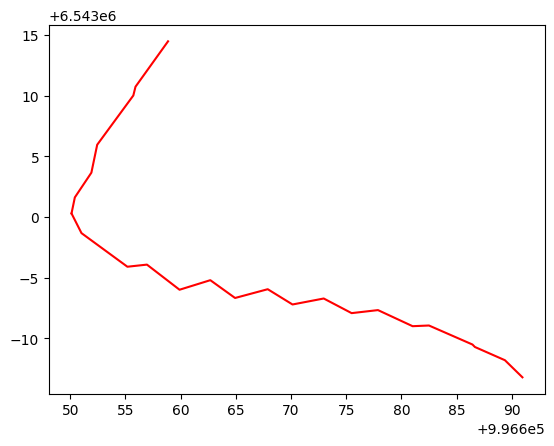

In [2]:
# The data are loaded, for example here as a MULTILINESTRING geometry.

wkt = "MULTILINESTRING((996650.116470902 6543000.302135976,996650.4178357278 6543001.6226440435,996651.9156040812 6543003.657303663,996652.4423765505 6543005.957021008,996655.7158302434 6543010.013807501,996655.9126520777 6543010.737483848,996658.861220837 6543014.477134332), (996690.9653817471 6542986.803184385,996689.3779384803 6542988.211877296,996686.663678412 6542989.299158129,996686.4368865794 6542989.504746181,996682.4986422878 6542991.069878142,996681.0169590351 6542991.013633349,996677.8785852245 6542992.338899864,996675.4910166311 6542992.089205852,996672.9643218932 6542993.294309987,996670.1372578226 6542992.801641864,996667.8920573386 6542994.059546746,996664.9329563477 6542993.336987803,996662.6910195594 6542994.80311256,996659.9024016755 6542994.016245508,996656.9491789015 6542996.084911368,996655.1794429084 6542995.911134065,996651.0192229722 6542998.678920098,996650.116470902 6543000.302135976))"
collection = tkl.TrackReader.parsMultiWkt(wkt)

collection.plot('r-')

## A function to filter a geometry using a band-stop Fourier filter 

In [3]:
def smooth_with_Fourier_filter(geom, wl_inf, wl_sup):
    
    N = len(geom)
    
    # Signal centering
    geom = geom.copy()
    c0 = geom.getCentroid(); 
    cx = c0.E
    cy = c0.N
    geom.translate(-cx, -cy)
    
    # Preserving endpoints
    ci = geom[0]
    cf = geom[-1]
    
    # Signal periodic extension
    geom_in = geom.reverse() + geom + geom.reverse()

    if geom_in.length() <= 0:
        return geom.copy()
    
    # band-stop filter
    signal_low_freq = tkl.filter_freq(geom_in, (1.0/wl_sup), mode=tkl.FILTER_SPATIAL, type=tkl.FILTER_LOW_PASS , dim=tkl.FILTER_XY)[N:2*N]
    signal_hgh_freq = tkl.filter_freq(geom_in, (1.0/wl_inf), mode=tkl.FILTER_SPATIAL, type=tkl.FILTER_HIGH_PASS, dim=tkl.FILTER_XY)[N:2*N]
    
    # High-pass / low-pass sum
    out = geom.copy()
    for i in range(N):
        out[i, "x"] = signal_low_freq[i, "x"] + signal_hgh_freq[i, "x"]
        out[i, "y"] = signal_low_freq[i, "y"] + signal_hgh_freq[i, "y"] 
        
    # Endpoint recovery
    out[0]  = ci
    out[-1] = cf   
        
    # Recentering the signal
    out.translate(cx, cy)
    
    return out

## Track Example Result

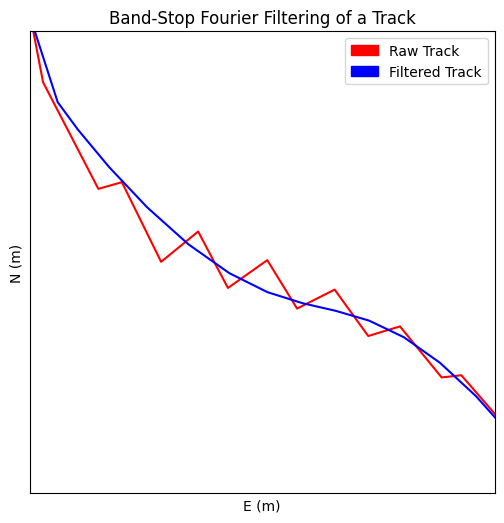

In [4]:
plt.figure(figsize=(6, 6))
collection.plot('r-')

for track in collection:
    s = smooth_with_Fourier_filter(track, 1, 5)
    s.plot('b-')

plt.xlim([996650, 996685])
plt.xticks([])
plt.ylim([6542988, 6543000])
plt.yticks([])

plt.title('Band-Stop Fourier Filtering of a Track')

red_patch = mpatches.Patch(color='red', label='Raw Track')
blue_patch = mpatches.Patch(color='blue', label='Filtered Track')

plt.legend(handles=[red_patch, blue_patch])